In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

folder = "/Users/jackc/Downloads/new_gals"
filenames = sorted([f for f in os.listdir(folder) if f.endswith('png')])

mean_rgb_list = []
bins_list = []
bin_width = 1
for filename in filenames:
    filepath = os.path.join(folder, filename)
    with Image.open(filepath) as img:
        img = np.array(img)
        y = np.zeros(shape = img.shape[:2], dtype = int)
        x = np.zeros(shape = img.shape[:2], dtype = int)
        for i in range(len(y[0])):
            y[i] += len(y[0]) - (i+1)
            x[:,i] += i
        r = np.sqrt((x - 32)**2 + (y - 32)**2) #assues galaxies are centered in each image, may change this assumption later
        # Flatten
        r_flat = r.ravel()
        R = img[:,:,0].ravel()
        G = img[:,:,1].ravel()
        B = img[:,:,2].ravel()
        # Define bins
        r_max = r_flat.max()
        bins = np.arange(0, r_max + bin_width, bin_width)
        bin_idx = np.digitize(r_flat, bins)
        r_bins = []
        mean_rgb = []
        counts = []
        for b in range(1, len(bins)+1):
            mask = bin_idx == b
            r_bins.append(bins[b-1] + bin_width/2)
            mean_rgb.append([
                np.mean(R[mask]),
                np.mean(G[mask]),
                np.mean(B[mask])])
            counts.append(np.sum(mask))
        mean_rgb_list.append(mean_rgb)
        bins_list.append(r_bins)
            
        

    
        

C:\Users\jackc\miniconda3\envs\torch_env\lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\jackc\miniconda3\envs\torch_env\lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


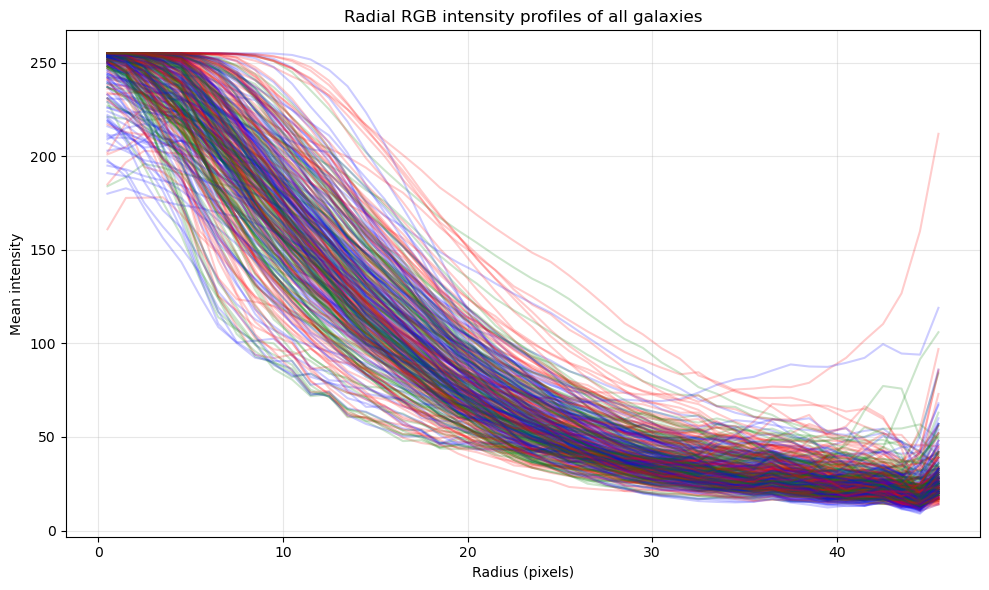

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

for mean_rgb, r_bins in zip(mean_rgb_list, bins_list):
    rgb = np.array(mean_rgb)
    plt.plot(r_bins, rgb[:,0], color='r', alpha=0.2)  
    plt.plot(r_bins, rgb[:,1], color='g', alpha=0.2) 
    plt.plot(r_bins, rgb[:,2], color='b', alpha=0.2)

plt.xlabel('Radius (pixels)')
plt.ylabel('Mean intensity')
plt.title('Radial RGB intensity profiles of all galaxies')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
import colorsys
mean_hue_list0 = []
bin_list0 = []
img_list0 = []
for filename in filenames:
    filepath = os.path.join(folder, filename)
    with Image.open(filepath) as img:
        img = np.array(img).astype(float) / 255.0  # scale RGB to 0-1
        
        y = np.zeros(shape = img.shape[:2], dtype=int)
        x = np.zeros(shape = img.shape[:2], dtype=int)
        for i in range(len(y[0])):
            y[i] += len(y[0]) - (i+1)
            x[:,i] += i
        
        r = np.sqrt((x - 32)**2 + (y - 32)**2)
        
        r_flat = r.ravel()
        R = img[:,:,0].ravel()
        G = img[:,:,1].ravel()
        B = img[:,:,2].ravel()
        
        hue_flat = np.array([colorsys.rgb_to_hsv(r_, g_, b_)[0] for r_, g_, b_ in zip(R, G, B)])
        
        r_max = r_flat.max()
        bins = np.arange(0, r_max + bin_width, bin_width)
        bin_idx = np.digitize(r_flat, bins)
        
        r_bins = []
        mean_hue = []
        counts = []
        for b in range(1, len(bins)+1):
            mask = bin_idx == b
            if np.any(mask):  
                r_bins.append(bins[b-1] + bin_width/2)
                mean_hue.append(np.mean(hue_flat[mask]))
                counts.append(np.sum(mask))
        
        mean_hue_list0.append(mean_hue)
        bin_list0.append(r_bins)
        img_list0.append(img)
        print(filename)


epoch_499_0 - Copy.png
epoch_499_0.png
epoch_499_1.png
epoch_499_10.png
epoch_499_100.png
epoch_499_101.png
epoch_499_102.png
epoch_499_103.png
epoch_499_104.png
epoch_499_105.png
epoch_499_106.png
epoch_499_107.png
epoch_499_108.png
epoch_499_109.png
epoch_499_11.png
epoch_499_110.png
epoch_499_111.png
epoch_499_112.png
epoch_499_113.png
epoch_499_114.png
epoch_499_115.png
epoch_499_116.png
epoch_499_117.png
epoch_499_118.png
epoch_499_119.png
epoch_499_12.png
epoch_499_120.png
epoch_499_121.png
epoch_499_122.png
epoch_499_123.png
epoch_499_124.png
epoch_499_125.png
epoch_499_126.png
epoch_499_127.png
epoch_499_13.png
epoch_499_14.png
epoch_499_15.png
epoch_499_16.png
epoch_499_17.png
epoch_499_18.png
epoch_499_19.png
epoch_499_2.png
epoch_499_20.png
epoch_499_21.png
epoch_499_22.png
epoch_499_23.png
epoch_499_24.png
epoch_499_25.png
epoch_499_26.png
epoch_499_27.png
epoch_499_28.png
epoch_499_29.png
epoch_499_3.png
epoch_499_30.png
epoch_499_31.png
epoch_499_32.png
epoch_499_33.png
e

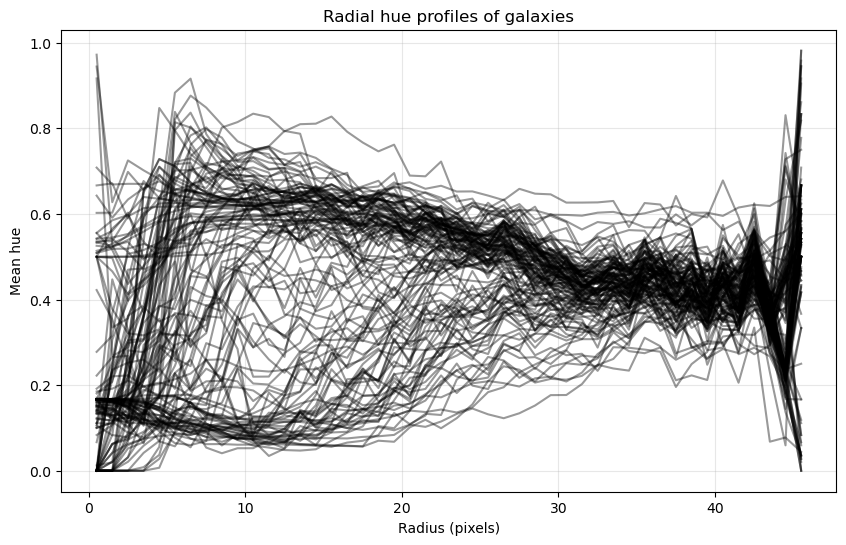

In [4]:
plt.figure(figsize=(10,6))
for r_bins, hues in zip(bin_list0, mean_hue_list0):
    plt.plot(r_bins, hues, alpha=0.4, color = 'black')
plt.xlabel('Radius (pixels)')
plt.ylabel('Mean hue')
plt.title('Radial hue profiles of galaxies')
plt.grid(alpha=0.3)
plt.show()

#we do appear to see two groups. both start at a similar starting hue, but one jumps up immedieately then slowly comes down, 
#while the other slowly increases untill they meet in the center again

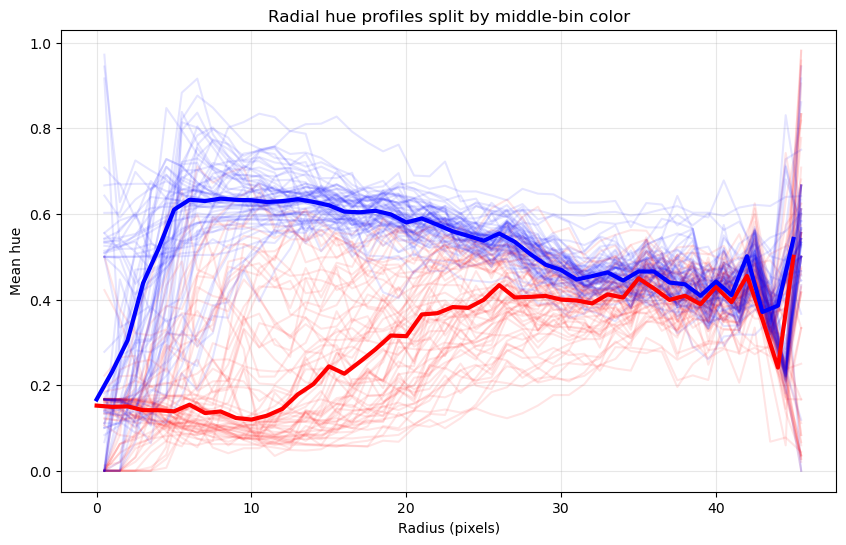

In [5]:
middle_hues0 = []
for r_bins, hues in zip(bin_list0, mean_hue_list0):
    mid_idx0 = len(hues)//3  # chose the place where I noticed the largest deviation between the two groups
    middle_hues0.append(hues[mid_idx0])
middle_hues0 = np.array(middle_hues0)

threshold0 = np.median(middle_hues0)  # split at median
group1_idx0 = np.where(middle_hues0 < threshold0)[0]
group2_idx0 = np.where(middle_hues0 >= threshold0)[0]

plt.figure(figsize=(10,6))


for idx in group1_idx0:
    plt.plot(bin_list0[idx], mean_hue_list0[idx], color='red', alpha=0.1)


for idx in group2_idx0:
    plt.plot(bin_list0[idx], mean_hue_list0[idx], color='blue', alpha=0.1)
img_list0 = np.array(img_list0) 

img_elliptical0 = img_list0[group1_idx0] 
img_spiral0 = img_list0[group2_idx0]

max_len10 = max(len(mean_hue_list0[i]) for i in group1_idx0)
stacked10 = np.full((len(group1_idx0), max_len10), np.nan)
for i, idx in enumerate(group1_idx0):
    L = len(mean_hue_list0[idx])
    stacked10[i,:L] = mean_hue_list0[idx]
median10 = np.nanmedian(stacked10, axis=0)

max_len20 = max(len(mean_hue_list0[i]) for i in group2_idx0)
stacked20 = np.full((len(group2_idx0), max_len20), np.nan)
for i, idx in enumerate(group2_idx0):
    L = len(mean_hue_list0[idx])
    stacked20[i,:L] = mean_hue_list0[idx]
median20 = np.nanmedian(stacked20, axis=0)

plt.plot(np.arange(len(median10)), median10, color='red', lw=3, label='Blue group median')
plt.plot(np.arange(len(median20)), median20, color='blue', lw=3, label='Red group median')

plt.xlabel('Radius (pixels)')
plt.ylabel('Mean hue')
plt.title('Radial hue profiles split by middle-bin color')
plt.grid(alpha=0.3)
plt.show()


In [6]:
import colorsys

folder = "/Users/jackc/Downloads/jack_colvin_projects-main/jack_colvin_projects-main/Astro_Projects/notebooks/Gan Project/Gan_Data"
filenames = sorted([f for f in os.listdir(folder) if f.endswith('jpg')])

mean_hue_list = []
bin_list = []
img_list = []
bin_width = 5
for filename in filenames:
    filepath = os.path.join(folder, filename)
    with Image.open(filepath) as img:
        img = np.array(img).astype(float) / 255.0  # scale RGB to 0-1
        
        y = np.zeros(shape = img.shape[:2], dtype=int)
        x = np.zeros(shape = img.shape[:2], dtype=int)
        for i in range(len(y[0])):
            y[i] += len(y[0]) - (i+1)
            x[:,i] += i
        
        r = np.sqrt((x - 64)**2 + (y - 64)**2)
        
        r_flat = r.ravel()
        R = img[:,:,0].ravel()
        G = img[:,:,1].ravel()
        B = img[:,:,2].ravel()
        
        hue_flat = np.array([colorsys.rgb_to_hsv(r_, g_, b_)[0] for r_, g_, b_ in zip(R, G, B)])
        

        r_max = r_flat.max()
        bins = np.arange(0, r_max + bin_width, bin_width)
        bin_idx = np.digitize(r_flat, bins)
        
        r_bins = []
        mean_hue = []
        counts = []
        for b in range(1, len(bins)+1):
            mask = bin_idx == b
            if np.any(mask):  
                r_bins.append(bins[b-1] + bin_width/2)
                mean_hue.append(np.mean(hue_flat[mask]))
                counts.append(np.sum(mask))
        
        mean_hue_list.append(mean_hue)
        bin_list.append(r_bins)
        img_list.append(img) 


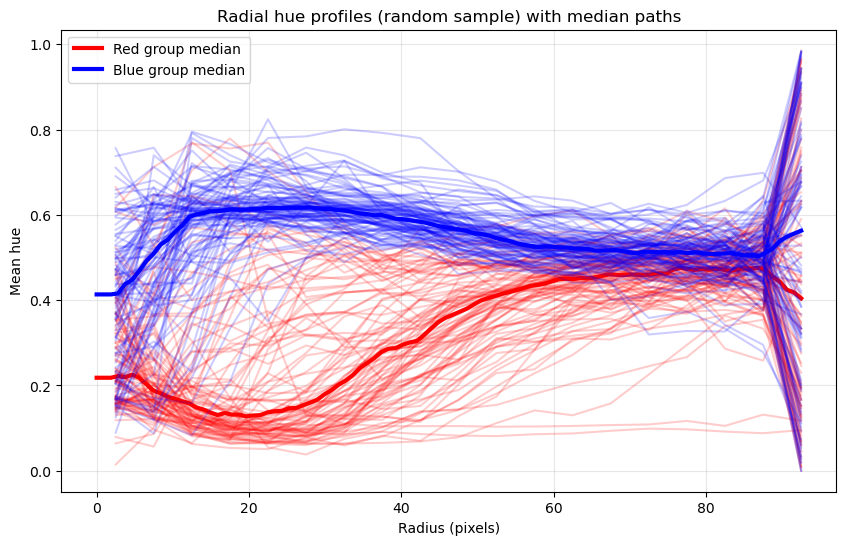

In [7]:
import numpy as np
import matplotlib.pyplot as plt

img_list = np.array(img_list)
np.random.seed(142)
sample_size = 200
total_galaxies = len(mean_hue_list)
sample_indices = np.random.choice(total_galaxies, size=min(sample_size, total_galaxies), replace=False)

middle_hues = []
for idx in sample_indices:
    hues = mean_hue_list[idx]
    mid_start = len(hues)//3
    mid_end = int(1.5*len(hues)//3)
    middle_hues.append(np.mean(hues[mid_start:mid_end]))
middle_hues = np.array(middle_hues)

threshold = np.median(middle_hues)
group1_idx = sample_indices[middle_hues < threshold]
group2_idx = sample_indices[middle_hues >= threshold]

img_elliptical = img_list[group1_idx] 
img_spiral = img_list[group2_idx]


r_max = max([bin_list[i][-1] for i in sample_indices])
common_bins = np.linspace(0, r_max, 100)

plt.figure(figsize=(10,6))

if len(group1_idx) > 0:
    interp_hues = []
    for idx in group1_idx:
        interp_hues.append(np.interp(common_bins, bin_list[idx], mean_hue_list[idx]))
        plt.plot(bin_list[idx], mean_hue_list[idx], color='red', alpha=0.2)
    interp_hues = np.array(interp_hues)
    median1 = np.nanmedian(interp_hues, axis=0)
    plt.plot(common_bins, median1, color='red', lw=3, label='Red group median')

                            
if len(group2_idx) > 0:
    interp_hues = []
    for idx in group2_idx:
        interp_hues.append(np.interp(common_bins, bin_list[idx], mean_hue_list[idx]))
        plt.plot(bin_list[idx], mean_hue_list[idx], color='blue', alpha=0.2)
    interp_hues = np.array(interp_hues)
    median2 = np.nanmedian(interp_hues, axis=0)
    plt.plot(common_bins, median2, color='blue', lw=3, label='Blue group median')

plt.xlabel('Radius (pixels)')
plt.ylabel('Mean hue')
plt.title('Radial hue profiles (random sample) with median paths')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


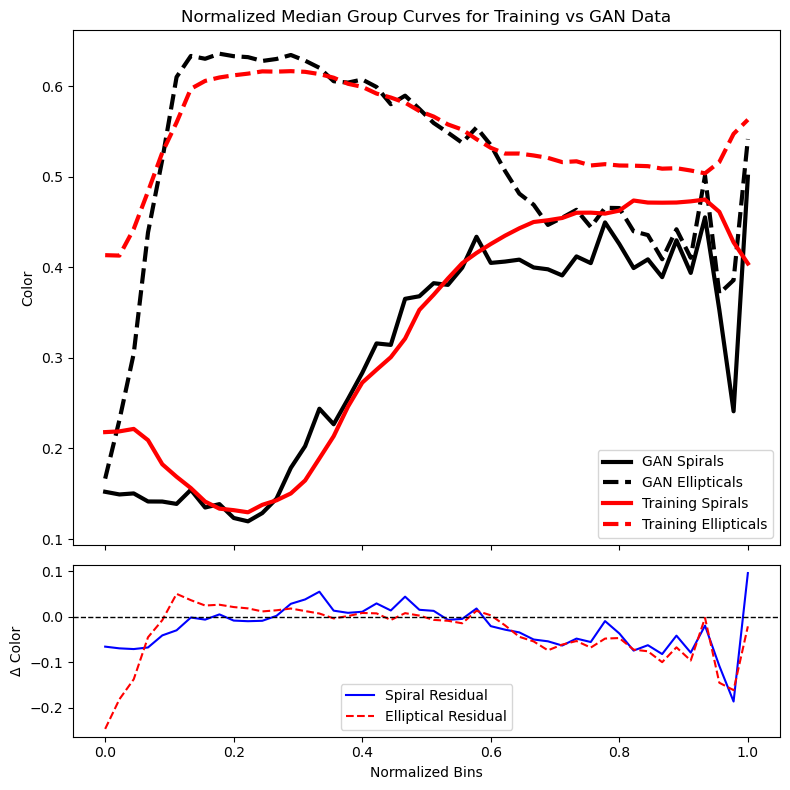

In [8]:
from scipy.interpolate import interp1d

# Define the normalized radial grids
r_gan_spiral = np.linspace(0, 1, len(median10))
r_gan_ellip  = np.linspace(0, 1, len(median20))
r_train_spiral = np.linspace(0, 1, len(median1))
r_train_ellip  = np.linspace(0, 1, len(median2))

# Interpolate training curves onto GAN grids
interp_spiral = interp1d(r_train_spiral, median1, kind='cubic', fill_value="extrapolate")
interp_ellip  = interp1d(r_train_ellip, median2, kind='cubic', fill_value="extrapolate")

train_interp_spiral = interp_spiral(r_gan_spiral)
train_interp_ellip  = interp_ellip(r_gan_ellip)

# Compute residuals (GAN - Training)
residual_spiral = median10 - train_interp_spiral
residual_ellip  = median20 - train_interp_ellip

# --- Plotting ---
fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Top panel: curves
ax[0].plot(r_gan_spiral, median10, color='black', lw=3, label='GAN Spirals')
ax[0].plot(r_gan_ellip, median20, color='black', lw=3, label='GAN Ellipticals', ls='--')
ax[0].plot(r_gan_spiral, train_interp_spiral, color='red', lw=3, label='Training Spirals')
ax[0].plot(r_gan_ellip, train_interp_ellip, color='red', lw=3, label='Training Ellipticals', ls='--')

ax[0].set_ylabel('Color')
ax[0].set_title('Normalized Median Group Curves for Training vs GAN Data')
ax[0].legend()

# Bottom panel: residuals
ax[1].plot(r_gan_spiral, residual_spiral, color='blue', label='Spiral Residual')
ax[1].plot(r_gan_ellip, residual_ellip, color='red', label='Elliptical Residual', ls='--')
ax[1].axhline(0, color='black', ls='--', lw=1)
ax[1].set_xlabel('Normalized Bins')
ax[1].set_ylabel('Δ Color')
ax[1].legend()

plt.tight_layout()
plt.show()

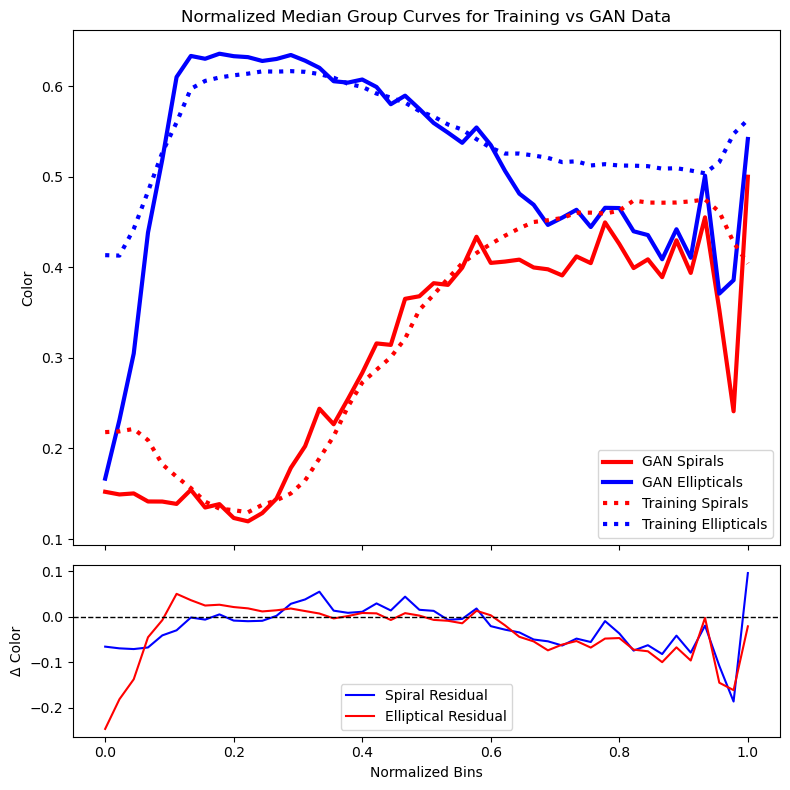

In [9]:
from scipy.interpolate import interp1d

r_gan_spiral = np.linspace(0, 1, len(median10))
r_gan_ellip  = np.linspace(0, 1, len(median20))
r_train_spiral = np.linspace(0, 1, len(median1))
r_train_ellip  = np.linspace(0, 1, len(median2))


interp_spiral = interp1d(r_train_spiral, median1, kind='cubic', fill_value="extrapolate")
interp_ellip  = interp1d(r_train_ellip, median2, kind='cubic', fill_value="extrapolate")

train_interp_spiral = interp_spiral(r_gan_spiral)
train_interp_ellip  = interp_ellip(r_gan_ellip)

residual_spiral = median10 - train_interp_spiral
residual_ellip  = median20 - train_interp_ellip


fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax[0].plot(r_gan_spiral, median10, color='red', lw=3, label='GAN Spirals')
ax[0].plot(r_gan_ellip, median20, color='blue', lw=3, label='GAN Ellipticals')
ax[0].plot(r_gan_spiral, train_interp_spiral, color='red', lw=3, label='Training Spirals', ls = ':')
ax[0].plot(r_gan_ellip, train_interp_ellip, color='blue', lw=3, label='Training Ellipticals', ls=':')

ax[0].set_ylabel('Color')
ax[0].set_title('Normalized Median Group Curves for Training vs GAN Data')
ax[0].legend()


ax[1].plot(r_gan_spiral, residual_spiral, color='blue', label='Spiral Residual')
ax[1].plot(r_gan_ellip, residual_ellip, color='red', label='Elliptical Residual')
ax[1].axhline(0, color='black', ls='--', lw=1)
ax[1].set_xlabel('Normalized Bins')
ax[1].set_ylabel('Δ Color')
ax[1].legend()

plt.tight_layout()
plt.show()

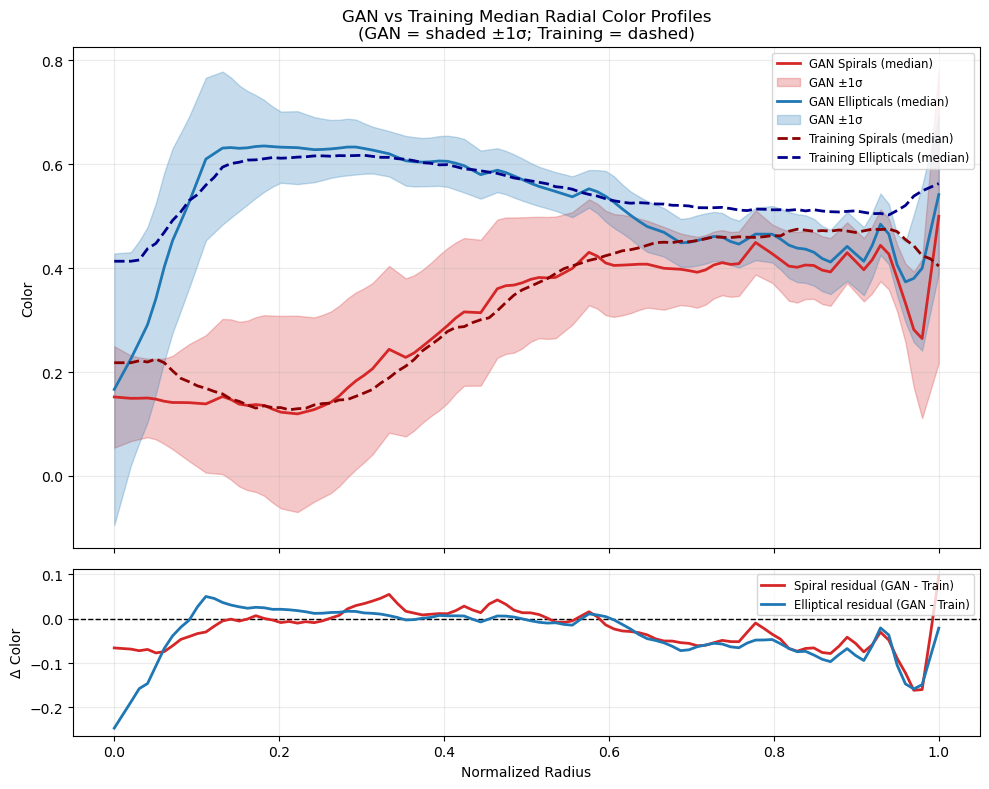

Reduced chi2 (spiral): 0.361
Reduced chi2 (elliptical): 0.596
Chi2 p-value Spiral: 1.000e+00, Elliptical: 9.995e-01


In [12]:
from scipy.interpolate import interp1d
from scipy.stats import chi2

median10 = np.nanmedian(stacked10, axis=0)
std10 = np.nanstd(stacked10, axis=0, ddof=1)
median20 = np.nanmedian(stacked20, axis=0)
std20 = np.nanstd(stacked20, axis=0, ddof=1)

n_bins = max(len(median10), len(median20), len(median1), len(median2))
x_common = np.linspace(0, 1, n_bins)

# we need to interpolate to a common basis since the training images are larger than the GAN outputs
def interp_to_common(arr, x_common, kind='linear'):
    x_src = np.linspace(0, 1, len(arr))
    fn = interp1d(x_src, arr, kind=kind, bounds_error=False, fill_value='extrapolate')
    return fn(x_common)


gan_spiral_med = interp_to_common(median10, x_common, kind='linear')
gan_spiral_std = interp_to_common(std10, x_common, kind='linear')

gan_ellip_med  = interp_to_common(median20, x_common, kind='linear')
gan_ellip_std  = interp_to_common(std20, x_common, kind='linear')


train_spiral_med = interp_to_common(median1, x_common, kind='linear')
train_ellip_med  = interp_to_common(median2, x_common, kind='linear')


res_spiral = gan_spiral_med - train_spiral_med
res_ellip  = gan_ellip_med  - train_ellip_med


fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10,8), 
                                     gridspec_kw={'height_ratios':[3,1]}, sharex=True)


ax_top.plot(x_common, gan_spiral_med, color='tab:red', lw=2, label='GAN Spirals (median)')
ax_top.fill_between(x_common, gan_spiral_med - gan_spiral_std, gan_spiral_med + gan_spiral_std,
                    color='tab:red', alpha=0.25, label='GAN ±1σ')

ax_top.plot(x_common, gan_ellip_med, color='tab:blue', lw=2, label='GAN Ellipticals (median)')
ax_top.fill_between(x_common, gan_ellip_med - gan_ellip_std, gan_ellip_med + gan_ellip_std,
                    color='tab:blue', alpha=0.25, label='GAN ±1σ')


ax_top.plot(x_common, train_spiral_med, '--', color='darkred', lw=2, label='Training Spirals (median)')
ax_top.plot(x_common, train_ellip_med, '--', color='darkblue', lw=2, label='Training Ellipticals (median)')

ax_top.set_ylabel('Color')
ax_top.set_title('GAN vs Training Median Radial Color Profiles\n(GAN = shaded ±1σ; Training = dashed)')
ax_top.legend(loc='upper right', fontsize='small')
ax_top.grid(alpha=0.25)


ax_bot.axhline(0, color='k', ls='--', lw=1)
ax_bot.plot(x_common, res_spiral, color='tab:red', lw=2, label='Spiral residual (GAN - Train)')
ax_bot.plot(x_common, res_ellip, color='tab:blue', lw=2, label='Elliptical residual (GAN - Train)')


ax_bot.set_xlabel('Normalized Radius')
ax_bot.set_ylabel('Δ Color')
ax_bot.legend(loc='upper right', fontsize='small')
ax_bot.grid(alpha=0.25)

plt.tight_layout()
plt.show()


eps_frac = 1e-3
gan_spiral_var = gan_spiral_std**2
gan_ellip_var  = gan_ellip_std**2
var_floor_spiral = np.nanmean(gan_spiral_var) * eps_frac
var_floor_ellip  = np.nanmean(gan_ellip_var)  * eps_frac
gan_spiral_var = np.where(np.isnan(gan_spiral_var) | (gan_spiral_var <= 0), var_floor_spiral, gan_spiral_var)
gan_ellip_var  = np.where(np.isnan(gan_ellip_var)  | (gan_ellip_var  <= 0), var_floor_ellip,  gan_ellip_var)

chi2_spiral = np.nansum((res_spiral**2) / gan_spiral_var)
chi2_ellip  = np.nansum((res_ellip**2)  / gan_ellip_var)
dof = np.sum(~np.isnan(gan_spiral_med)) 

reduced_chi2_spiral = chi2_spiral / dof
reduced_chi2_ellip  = chi2_ellip  / dof

print(f"Reduced chi2 (spiral): {reduced_chi2_spiral:.3f}")
print(f"Reduced chi2 (elliptical): {reduced_chi2_ellip:.3f}")


p_spiral = 1.0 - chi2.cdf(chi2_spiral, df=dof)
p_ellip  = 1.0 - chi2.cdf(chi2_ellip, df=dof)
print(f"Chi2 p-value Spiral: {p_spiral:.3e}, Elliptical: {p_ellip:.3e}")
